# History Matching (Manual Configuration)

## Libraries, global parameters, and initialization

The basic libraries for numerical analysis are used throughout the notebook, namely, numpy and pandas. 

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import history_matching as hm

%matplotlib inline

## Example scenario: a stochastic SIR model

Let's define a stochastic SIR model using the Tao-leap algorithm. This is the model we will calibrate using History Matching. Furthermore, we will use this model to generate synthetic data. Our calibration process will try to recover the parameters that generated the synthetic data.

### Model definition

In [2]:
class SIR:
    """ A stochastic SIR model. 
    """
    def __init__( self, 
                  beta=1.2,  gamma=0.3,        # transition rates
                  s0=990,  i0=10,  r0=0,       # initial conditions
                  n_days=20,                   # number of days to simulate
                  step=0.1,                    # step size in days (<=1)
                  seed=None,                   # random number seed
                 ):
        """ Create and initialize the SIR model.
        
        Args:
            beta   : Transmission rate (>0).
            gamma  : Inverse of the average transmission period (>0).
            s0     : Initial number of succeptible individuals (non-negative 
                     integer).
            i0     : Initial number of infected individuals (non-negative int).
            r0     : Initial number of recovered individuals (non-negative int).
            n_days : Number of days to simulate (positive integer).
            step   : Step size in days (integer between 0 and 1).
            seed   : Seed for the random number generator.
        """
        # Verify inputs
        assert( beta > 0 )
        assert( gamma > 0 )
        assert( s0 >= 0 )
        assert( i0 >= 0 )
        assert( r0 >= 0 )
        assert( n_days > 0 )
        assert( step > 0 )
        assert( step <= 1 )
        
        # Initialize variables
        self.beta = beta
        self.gamma = gamma
        self.s0 = int( s0 )
        self.i0 = int( i0 )
        self.r0 = int( r0 )
        self.n_days = int( n_days )
        self.step = step
        self.seed = seed
        self.simulation_complete = False

    
    def run( self ):
        """ Run the simulation and return S, I, and R arrays.
        """    
        # Initialization
        n_steps = math.ceil( (self.n_days-1)/self.step )
        steps_per_day = int( 1/self.step )
        N = self.s0 + self.i0 + self.r0    # population size             
        
        s = np.zeros( n_steps+1, dtype=int )
        i = np.zeros( n_steps+1, dtype=int )
        r = np.zeros( n_steps+1, dtype=int )        
        s[0] = self.s0
        i[0] = self.i0
        r[0] = self.r0

        s_daily = np.zeros( self.n_days, dtype=int )
        i_daily = np.zeros( self.n_days, dtype=int )
        r_daily = np.zeros( self.n_days, dtype=int )
        s_daily[0] = s[0]
        i_daily[0] = i[0]
        r_daily[0] = r[0]

        if self.seed is not None:
            np.random.seed( seed=self.seed )

        # Compute events per time step
        for j in range(1, n_steps+1):
            lambda_transmission = ( self.beta * s[j-1] * i[j-1] / N ) * self.step
            lambda_recovery = self.gamma * i[j-1] * self.step
                       
            delta_Mt = np.random.poisson( lambda_transmission )
            delta_Mr = np.random.poisson( lambda_recovery )
            
            s[j] = max( s[j-1] - delta_Mt           , 0 )
            i[j] = max( i[j-1] + delta_Mt - delta_Mr, 0 )
            r[j] = r[j-1] + delta_Mr

        # Count events per day
        for j in range(1, self.n_days):
            k = j*steps_per_day
            s_daily[j] = s[k]
            i_daily[j] = i[k]
            r_daily[j] = r[k]
        
        # Finalize and return
        self.s = s_daily
        self.i = i_daily
        self.r = r_daily
        self.simulation_complete = True
        return s_daily, i_daily, r_daily
    

    def get_incidence( self ): 
        """ Return array with the incidence.
        """
        if not self.simulation_complete:
            self.run()
        n = len(self.i)
        incidence = np.zeros(n)
        incidence[0] = 0
        for j in range(1, n):
            incidence[j] = self.s[j-1] - self.s[j]
        return incidence


    def plot( self ): 
        """ Display figure with S, I, and R curves.
        """
        if not self.simulation_complete:
            self.run()
        x = range(0, self.n_days)
        title = f'beta = {self.beta};  gamma = {self.gamma}'
        plt.figure()
        plt.plot( x, self.s, 'g')
        plt.plot( x, self.i, 'r')
        plt.plot( x, self.r, 'b')
        plt.legend(['S', 'I', 'R'])
        plt.ylabel('cases')
        plt.xlabel('days')
        plt.title( title )
        plt.grid(linestyle=':')
 

    def plot_incidence( self ): 
        """ Display figure with the incidence.
        """
        if not self.simulation_complete:
            self.run()
        incidence = self.get_incidence()
        x = range(0, self.n_days)
        title = f'beta = {self.beta};  gamma = {self.gamma}'
        plt.figure()
        plt.plot( x, incidence, 'b' )
        plt.ylabel('new cases')
        plt.xlabel('days')
        plt.title(title)
        plt.grid(linestyle=':')

### Running our model

Our model should be easy to run. Let's try it with a few different parameters:

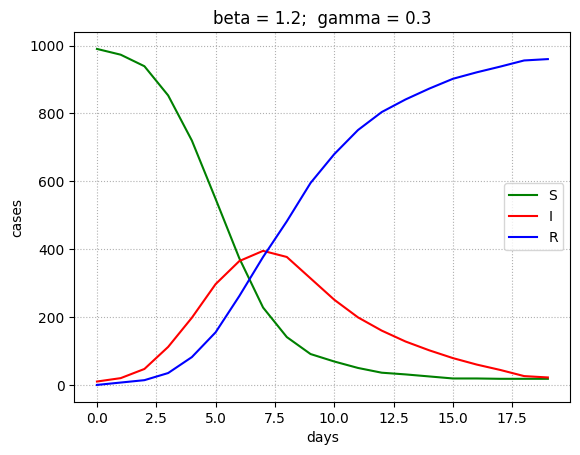

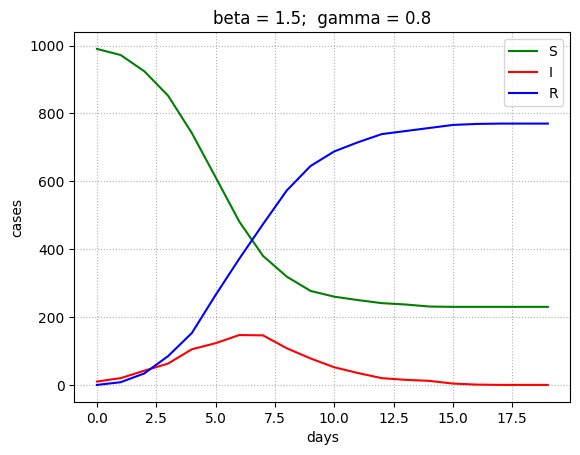

In [3]:
sim1 = SIR()
sim2 = SIR( beta=1.5, gamma=0.8 )
sim1.plot()
sim2.plot()

### Synthetic data

Next we generate synthetic data for the demonstration of the History Matching (HM) algorithm. We define specific values of the `beta` and `gamma` parameters. We will later use to recover (i.e., estimate) those parameters.

In [4]:
# Define model parameters
beta_true = 1.3
gamma_true = 0.5
rand_seed = 0
population_size = 10_000
n_seed_infections = 100

In [5]:
# Run the simulation
true_model = SIR( beta  = beta_true,
                  gamma = gamma_true,
                  s0    = population_size - n_seed_infections,
                  i0    = n_seed_infections,
                  seed  = rand_seed
                 )
S, I, R = true_model.run()

In [6]:
# Generate simulated observation data
incidence_data = true_model.get_incidence()
data = pd.DataFrame( { 'day' : range(0,len(incidence_data)), 
                       'incidence' : incidence_data
                      } ).set_index('day')

Let's quickly glance at our data:

In [7]:
data.head()

,incidence
day,
0,0.0
1,177.0
2,415.0
3,762.0
4,1246.0


<Axes: xlabel='day'>

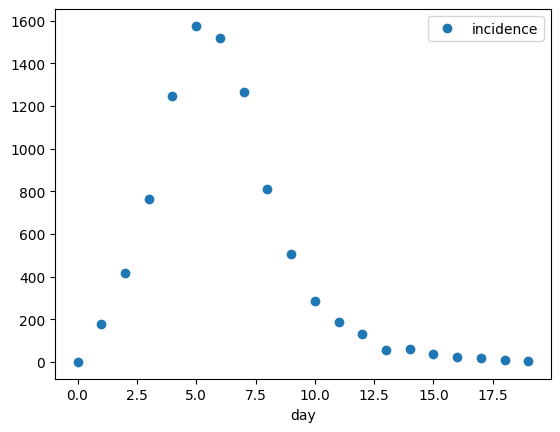

In [8]:
data.plot( style='o' )

## Running a History Matching iteration

### The History Matching algorithm

### Selecting the target observation

### Iteration setup

In [9]:
parameter_space = pd.DataFrame( { # name      ,   min , max
                                  'beta'      : [ 0.01, 5.0 ],
                                  'gamma'     : [ 0.1 , 1.0 ],
                                  'rand_seed' : [ 0   , 1e5 ]
                                 }, index = ['minimum', 'maximum']
                               ).transpose()
parameter_space.index.name = 'parameter'
parameter_space.head()

,minimum,maximum
parameter,,
beta,0.01,5.0
gamma,0.10,1.0
rand_seed,0.00,100000.0


In [10]:
n_samples = 100
initial_samples = pd.DataFrame( { param: np.random.uniform( parameter_space.loc[param, 'minimum'], 
                                                            parameter_space.loc[param, 'maximum'],
                                                            n_samples
                                                           ) for param in parameter_space.index } )
initial_samples['iteration'] = 0
initial_samples.head()

,beta,gamma,rand_seed,iteration
0,2.093521,0.170421,52658.402882,0
1,3.910093,0.434158,53794.577915,0
2,3.471798,0.789932,93766.309396,0
3,4.582538,0.719815,30518.870269,0
4,1.304293,0.737184,98343.397823,0


In [11]:
observations = pd.DataFrame()
observations['feature'] = 'incidence_' + data.index.astype(str)
observations['mean'   ] = data['incidence']
observations['variance'] = 100
observations.head()

,feature,mean,variance
0,incidence_0,0.0,100
1,incidence_1,177.0,100
2,incidence_2,415.0,100
3,incidence_3,762.0,100
4,incidence_4,1246.0,100


In [12]:
status = hm.Situation( parameter_space = parameter_space.reset_index(),
                       observations = observations,
                       initial_sample_points = initial_samples
                      )

In [13]:
global_conf = hm.Config( max_iterations = 1,
                         feature_selection_mode = 'manual',
                         candidates_per_iteration = n_samples,
                         implausibility_threshold = 3,
                         non_implausible_target = 0.01,
                         model_discrepancy = 5
                        )

We need a wrapper for our model:  (NOTE: Can we just provide the outputs of the model? Or this wrapper being a callback with a list of points to run?)

In [14]:
def model_wrapper( iteration: int, points: pd.DataFrame, config: hm.Config) -> pd.DataFrame:

    # Run simulations
    results = pd.DataFrame()
    for index, parameters in enumerate(points.itertuples()):

        this_run = SIR( beta  = parameters.beta,
                         gamma = parameters.gamma,
                         s0    = population_size - n_seed_infections,
                         i0    = n_seed_infections,
                         seed  = int(parameters.rand_seed)
                       )
        results[index] = this_run.get_incidence()

    # Format output dataframe
    out = results.transpose().add_prefix('incidence_')
    out['iteration'] = iteration
    out['replicate'] = np.zeros( len(points), np.uint32 )
    out['beta'] = points['beta']
    out['gamma'] = points['gamma']
    out['rand_seed'] = points['rand_seed']
    return out

In [15]:
model_wrapper( 0, initial_samples, global_conf ).head()

,incidence_0,incidence_1,incidence_2,incidence_3,incidence_4,incidence_5,incidence_6,incidence_7,incidence_8,incidence_9,...,incidence_15,incidence_16,incidence_17,incidence_18,incidence_19,iteration,replicate,beta,gamma,rand_seed
0,0.0,469.0,1993.0,4253.0,2512.0,547.0,91.0,25.0,6.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0,0,2.093521,0.170421,52658.402882
1,0.0,1942.0,6808.0,1080.0,59.0,9.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,3.910093,0.434158,53794.577915
2,0.0,1097.0,4812.0,3224.0,520.0,98.0,26.0,8.0,11.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0,0,3.471798,0.789932,93766.309396
3,0.0,2829.0,6438.0,551.0,56.0,10.0,2.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0,4.582538,0.719815,30518.870269
4,0.0,172.0,314.0,526.0,636.0,863.0,958.0,936.0,769.0,618.0,...,82.0,53.0,31.0,20.0,3.0,0,0,1.304293,0.737184,98343.397823


In [16]:
conf = hm.Recipe()
conf.run_simulators = model_wrapper

### Running the iteration

In [17]:
hm.do_step( situation=status, 
            recipe = conf,
            config = global_conf
           ) 

Concatenating 0 existing results with 100 new results.
hello
MANUAL mode
Generating 100 new samples...
lhs(100):  3008900 ns
Found 100 plausible candidates.
100 non-implausible candidates so far from 100 candidates (1.0).


True

### Evaluating the performance of the emulator

### Evaluating reductions in the parameter space

## Running multiple HM iterations

## HM calibration results

### Trajectory selection